In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from typing import List, Dict, Tuple
import io
import sys
import pickle
import itertools
import datetime
import copy
from tqdm import tqdm
import random
import csv
import json
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

import torch

import torch.optim.lr_scheduler as lr_scheduler
import torch_geometric
import torch_geometric.transforms as T
import torch_geometric.transforms
import torch_geometric.datasets
import torch_geometric.nn
from torch_geometric.utils import to_networkx

from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore', module='sklearn')

In [2]:
from env_variables import *
from utils_helpers import *

In [3]:
results_output_dir = "./results"
if not os.path.exists(results_output_dir):
    os.makedirs(results_output_dir)

# Bipartite Matching Algorithms

In [11]:
def get_job_params_bipartite():
    data_types = [
                    #"Synthetic_random_walk_2D_z_normal_distribution",
                    #"Synthetic_lin_1D_y_random_walk_z_fixed",
                    #"Synthetic_lin_1D_y_fixed_z_fixed",
                    #"Real_automatic",
                    "Real"
    ]

    combinations = {
        "data_type_train": data_types,
        "model_type":[
                        "Hopcroft_Karp",
                        "Minimum Weight"
        ],
        "knn_inter_nodes":[
                            #"min",
                            7,
                            #10
        ],
        "knn_inter_nodes_max": [7],
       "knn_intra_nodes":[0],
        "normalize":[
                    True, 
                     #False
                    ],
        "node_feats":[[
            'Y', 
            'X', 
            'Z', 
            'node_type', 
            'ID'
        ]],
        "edge_feats":[[
    'source',
    'target',
     'edge_label',
     'delta_x',
     'delta_y',
     'delta_z',
     'weight',
     'edge_type',
     'angle_orientation_theta',
     'angle_orientation_phi']],
    }


    job_parameters = []


    # Generate all possible combinations of the dictionary values
    for values in itertools.product(*combinations.values()):
        # Generate a dictionary for the combination of values
        job_dict = dict(zip(combinations.keys(), values))
        job_dict["scale_features"] = True if "Real" in job_dict["data_type_train"] else False
        job_parameters.append(job_dict)
    
    return job_parameters

In [12]:
def get_graph_list_bipartite(job_parameters, debug = False):
    #build dataframes
    graph_list_dict_bipartite = {}

    for params in tqdm(job_parameters):

        params_list = [params["data_type_train"], params["knn_inter_nodes"], params["knn_intra_nodes"], 
                                        params["knn_inter_nodes_max"],params["normalize"],
                                        params["scale_features"], str(params["node_feats"]), str(params["edge_feats"])]
        params_list = [str(param_) for param_ in params_list]
        graph_key = "_".join(params_list)

        if graph_key not in graph_list_dict_bipartite:
            graph_list = get_graph_list(params["data_type_train"], params["knn_inter_nodes"], params["knn_intra_nodes"], 
                                            params["knn_inter_nodes_max"], normalize = params["normalize"],
                                            scale_feats = params["scale_features"],
                                            node_feats = params["node_feats"], edge_feats = params["edge_feats"],
                                            shuffle = False)



            graph_list_dict_bipartite[graph_key] = graph_list

    return graph_list_dict_bipartite

In [13]:
def train_bipartite(graph_list_dict_bipartite, job_parameters, debug = False, make_plots = True):
    results_list_mf = []

    for params in job_parameters:
        print("\n\n\n####################################")
        metrics_list_bipartite = []

        params_list = [params["data_type_train"], params["knn_inter_nodes"], params["knn_intra_nodes"], 
                                        params["knn_inter_nodes_max"],params["normalize"],
                                        params["scale_features"], str(params["node_feats"]), str(params["edge_feats"])]
        params_list = [str(param_) for param_ in params_list]
        graph_key = "_".join(params_list)
        graph_list = graph_list_dict_bipartite[graph_key]

        for graph in graph_list:
            graph_id, nodes_df, edges_df, edges_df_knn, k_intra, k_inter = graph.graph_id, graph.nodes_df, graph.edges_df, graph.edges_df_knn, graph.k_intra, graph.k_inter
            print("Graph_ID:",graph_id,"K_INTRA:",k_intra, "K_INTER:",k_inter)

            edges_df_bipartite_graph = edges_df_knn.copy()
            nx_G_knn = nx_build_graph(nodes_df, edges_df_bipartite_graph)

            model_type = params["model_type"]

            #get the bipartite edges_list
            if(model_type=="Hopcroft_Karp"):
                nx_bipartite_edges_list = nx.bipartite.maximum_matching(nx_G_knn)
            elif(model_type=="Eppstein"):
                nx_bipartite_edges_list = nx.bipartite.eppstein_matching(nx_G_knn)
            elif(model_type=="Minimum Weight"):
                nx_bipartite_edges_list = nx.bipartite.minimum_weight_full_matching(nx_G_knn)
            else:
                raise ValueError("Model not implemented!")

            #convert to Dataframe
            edges_df_bipartite = nx_convert_dict_to_edges_df(nx_bipartite_edges_list)
            #apply the pred labels to edges_df_bipartite, taking as input the edges_df_knn
            edges_df_bipartite["edge_label"] = 1
            edges_df_bipartite = apply_edges_df_label(edges_df_bipartite, edges_df_knn)

            metrics_bipartite, edge_labels_string_bipartite = eval_edges_df(edges_df, edges_df_bipartite)
            metrics_list_bipartite.append(metrics_bipartite)

            print(json.dumps(metrics_bipartite, indent = 1))

            #Save results to file
            bipartite_results_array = pred_df_to_csv(edges_df_bipartite, graph.nodes_df_original)
            output_file_dir =  results_output_dir+"/"+params["data_type_train"]+"_"+params["model_type"]+"_" +\
                                    str(params["knn_inter_nodes"])+"_"+str(params["knn_intra_nodes"])+"/"
            if not os.path.exists(output_file_dir):
                os.makedirs(output_file_dir)
            output_file_path = os.path.join(output_file_dir, graph.graph_id)
            array_to_csv(bipartite_results_array, output_file_path)

            if(make_plots):
                fig_bipartite = df_make_plot(nodes_df, edges_df_bipartite, edge_labels_string_bipartite, "Bipartite")
                plt.show()

        ####################################
        ### Aggregate Metrics at the end  ##
        ####################################

        metrics_bipartite_aggregated = aggregate_metrics(metrics_list_bipartite)
        print(json.dumps(metrics_bipartite_aggregated,indent = 1))

        result_bipartite = {}
        result_bipartite["aggregated_metrics"] = metrics_bipartite_aggregated
        params["angle_features"] = "NA"
        params["constraints"] = "NA"
        result_bipartite["job_parameters"] = params
        results_list_mf.append(result_bipartite)
    return results_list_mf

In [14]:
def plot_results_bipartite(results_list_bipartite):
    plot_df_mf = plot_table(results_list_bipartite, metrics_dict_entries = [None])
    plot_df_mf = plot_df_mf.sort_values(by=["K Inter", 'Algorithm', 'Data Train', 'Data Test'])
    display(plot_df_mf)
    plot_df_mf = plot_df_mf.drop(["Data Train", "Data Test", "Scale"], axis=1)
    display(plot_df_mf)
    print(plot_df_to_latex(plot_df_mf))
    return plot_df_mf

In [15]:
job_parameters_bipartite = get_job_params_bipartite()

In [16]:
graph_list_dict_bipartite = get_graph_list_bipartite(job_parameters_bipartite, debug = False)

100%|██████████| 2/2 [00:32<00:00, 16.44s/it]





####################################
Graph_ID: Crop1.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 13,
 "fp": 58,
 "tn": 368,
 "fn": 58,
 "acc": 0.767,
 "precision": 0.183,
 "recall": 0.183,
 "f1_score": 0.183,
 "tp_percent": 0.183,
 "tp_total_count": 71
}


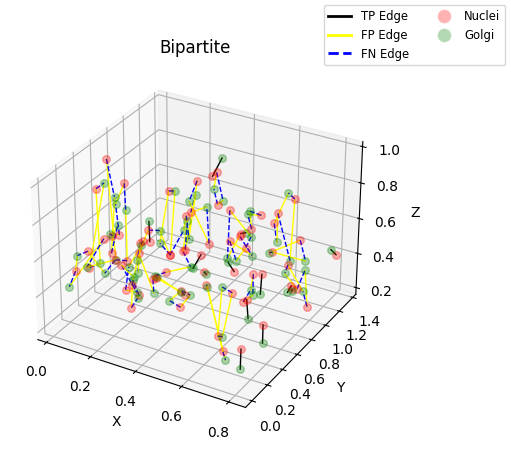

Graph_ID: Crop2.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 15,
 "fp": 76,
 "tn": 470,
 "fn": 76,
 "acc": 0.761,
 "precision": 0.165,
 "recall": 0.165,
 "f1_score": 0.165,
 "tp_percent": 0.165,
 "tp_total_count": 91
}


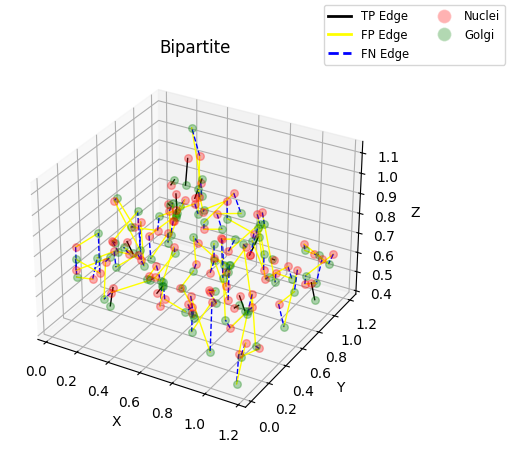

Graph_ID: Crop3.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 12,
 "fp": 49,
 "tn": 317,
 "fn": 49,
 "acc": 0.77,
 "precision": 0.197,
 "recall": 0.197,
 "f1_score": 0.197,
 "tp_percent": 0.197,
 "tp_total_count": 61
}


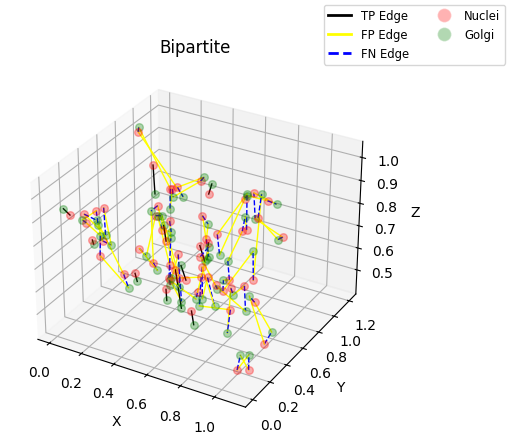

Graph_ID: Crop4.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 5,
 "fp": 32,
 "tn": 190,
 "fn": 32,
 "acc": 0.753,
 "precision": 0.135,
 "recall": 0.135,
 "f1_score": 0.135,
 "tp_percent": 0.135,
 "tp_total_count": 37
}


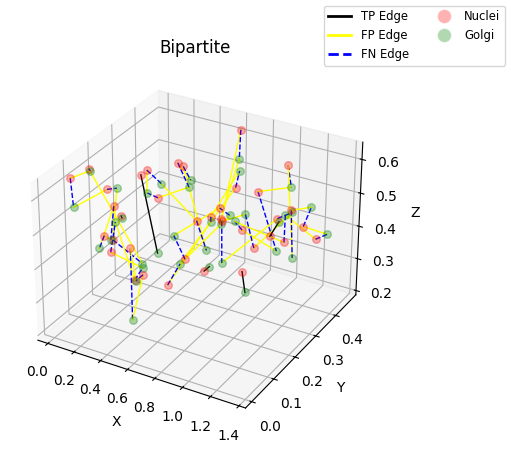

Graph_ID: Crop5_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 11,
 "fp": 35,
 "tn": 241,
 "fn": 35,
 "acc": 0.783,
 "precision": 0.239,
 "recall": 0.239,
 "f1_score": 0.239,
 "tp_percent": 0.239,
 "tp_total_count": 46
}


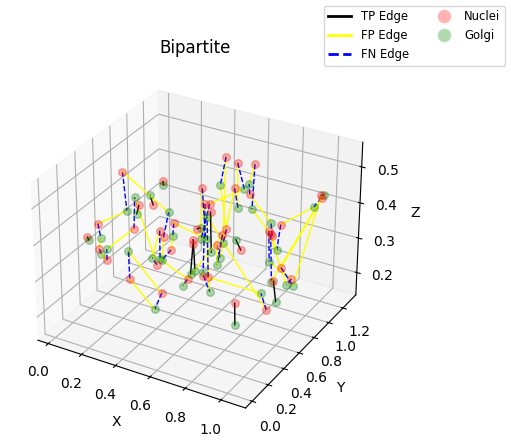

Graph_ID: Crop6_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 10,
 "fp": 40,
 "tn": 260,
 "fn": 40,
 "acc": 0.771,
 "precision": 0.2,
 "recall": 0.2,
 "f1_score": 0.2,
 "tp_percent": 0.2,
 "tp_total_count": 50
}


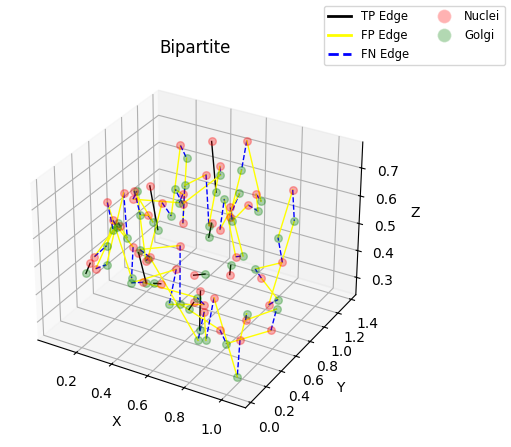

Graph_ID: Crop7_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 16,
 "fp": 74,
 "tn": 466,
 "fn": 74,
 "acc": 0.765,
 "precision": 0.178,
 "recall": 0.178,
 "f1_score": 0.178,
 "tp_percent": 0.178,
 "tp_total_count": 90
}


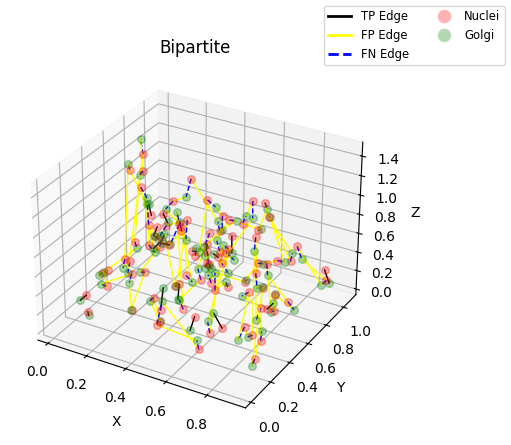

Graph_ID: Crop8_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 9,
 "fp": 27,
 "tn": 189,
 "fn": 27,
 "acc": 0.786,
 "precision": 0.25,
 "recall": 0.25,
 "f1_score": 0.25,
 "tp_percent": 0.25,
 "tp_total_count": 36
}


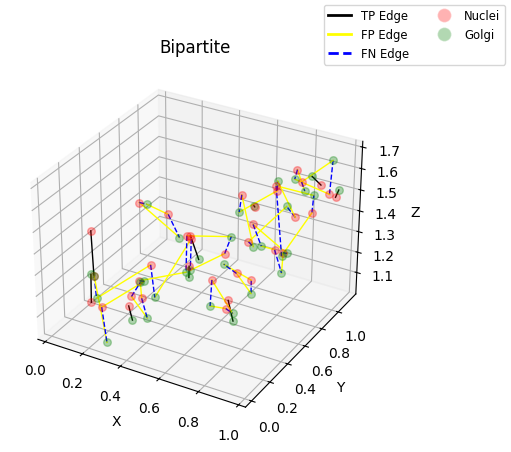

{
 "acc": 0.7695000000000001,
 "precision": 0.193375,
 "recall": 0.193375,
 "f1_score": 0.193375,
 "tp": 91,
 "fp": 391,
 "tn": 2501,
 "fn": 391,
 "tp_percent": 0.193375,
 "tp_total_count": 482
}



####################################
Graph_ID: Crop1.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 67,
 "fp": 4,
 "tn": 422,
 "fn": 4,
 "acc": 0.984,
 "precision": 0.944,
 "recall": 0.944,
 "f1_score": 0.944,
 "tp_percent": 0.944,
 "tp_total_count": 71
}


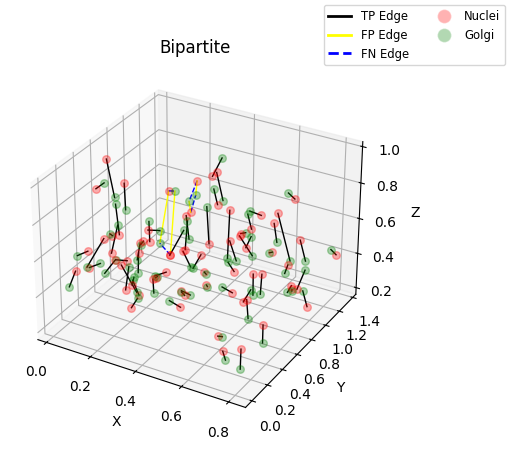

Graph_ID: Crop2.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 84,
 "fp": 7,
 "tn": 539,
 "fn": 7,
 "acc": 0.978,
 "precision": 0.923,
 "recall": 0.923,
 "f1_score": 0.923,
 "tp_percent": 0.923,
 "tp_total_count": 91
}


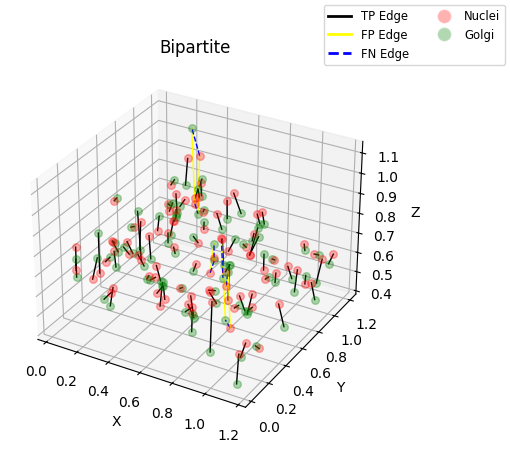

Graph_ID: Crop3.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 57,
 "fp": 4,
 "tn": 362,
 "fn": 4,
 "acc": 0.981,
 "precision": 0.934,
 "recall": 0.934,
 "f1_score": 0.934,
 "tp_percent": 0.934,
 "tp_total_count": 61
}


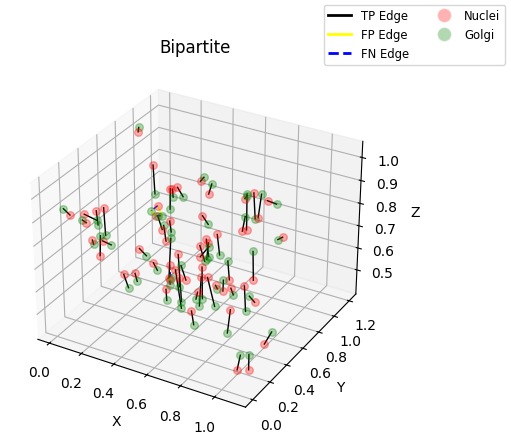

Graph_ID: Crop4.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 33,
 "fp": 4,
 "tn": 218,
 "fn": 4,
 "acc": 0.969,
 "precision": 0.892,
 "recall": 0.892,
 "f1_score": 0.892,
 "tp_percent": 0.892,
 "tp_total_count": 37
}


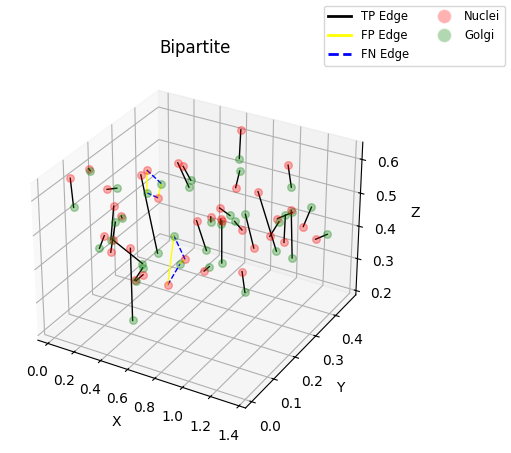

Graph_ID: Crop5_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 46,
 "fp": 0,
 "tn": 276,
 "fn": 0,
 "acc": 1.0,
 "precision": 1.0,
 "recall": 1.0,
 "f1_score": 1.0,
 "tp_percent": 1.0,
 "tp_total_count": 46
}


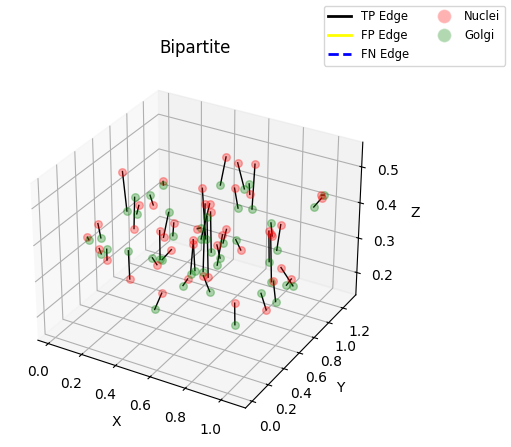

Graph_ID: Crop6_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 50,
 "fp": 0,
 "tn": 300,
 "fn": 0,
 "acc": 1.0,
 "precision": 1.0,
 "recall": 1.0,
 "f1_score": 1.0,
 "tp_percent": 1.0,
 "tp_total_count": 50
}


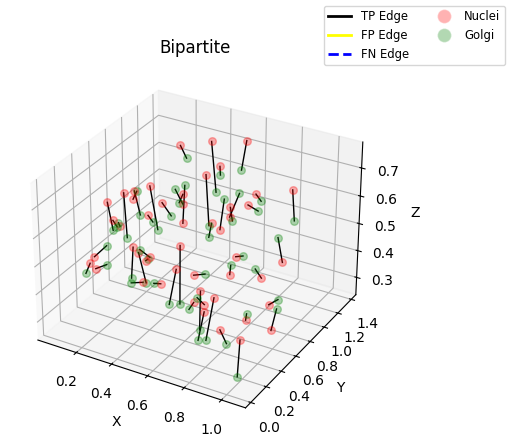

Graph_ID: Crop7_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 84,
 "fp": 6,
 "tn": 534,
 "fn": 6,
 "acc": 0.981,
 "precision": 0.933,
 "recall": 0.933,
 "f1_score": 0.933,
 "tp_percent": 0.933,
 "tp_total_count": 90
}


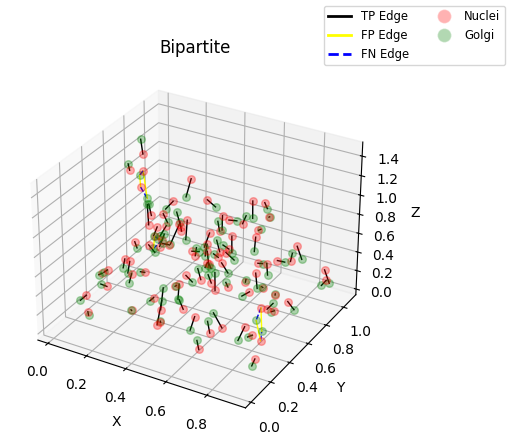

Graph_ID: Crop8_BC.csv K_INTRA: 0 K_INTER: 7
{
 "tp": 34,
 "fp": 2,
 "tn": 214,
 "fn": 2,
 "acc": 0.984,
 "precision": 0.944,
 "recall": 0.944,
 "f1_score": 0.944,
 "tp_percent": 0.944,
 "tp_total_count": 36
}


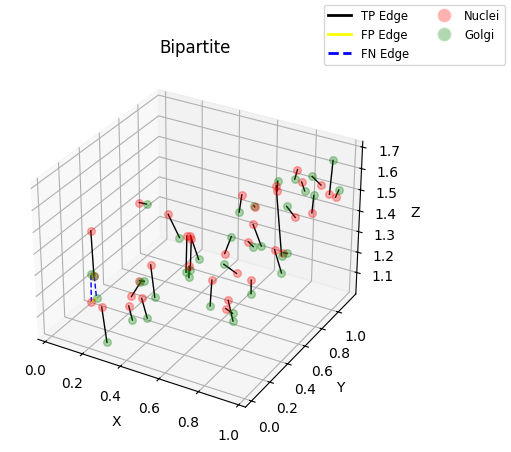

{
 "acc": 0.984625,
 "precision": 0.94625,
 "recall": 0.94625,
 "f1_score": 0.94625,
 "tp": 455,
 "fp": 27,
 "tn": 2865,
 "fn": 27,
 "tp_percent": 0.94625,
 "tp_total_count": 482
}


In [17]:
results_list_bipartite = train_bipartite(graph_list_dict_bipartite, job_parameters_bipartite, debug = True, make_plots = True)

In [18]:
output_df = plot_results_bipartite(results_list_bipartite) 

,Algorithm,Data Train,Data Test,Constraints,Normalize,Scale,Node Feat.,Edge Feat.,K Intra,K Inter,...,Accuracy,Precision,Recall,F1-Score,TP Percent,TP Total Count,TP,FP,TN,FN
0,Hopcroft_Karp,Real,Real,NA,True,True,"[Y, X, Z, node_type, ID]","[source, target, edge_label, delta_x, delta_y,...",0,7,...,0.770,0.193,0.193,0.193,0.193,482,91,391,2501,391
1,Minimum Weight,Real,Real,NA,True,True,"[Y, X, Z, node_type, ID]","[source, target, edge_label, delta_x, delta_y,...",0,7,...,0.985,0.946,0.946,0.946,0.946,482,455,27,2865,27


,Algorithm,Constraints,Normalize,Node Feat.,Edge Feat.,K Intra,K Inter,ROC AUC Score,Accuracy,Precision,Recall,F1-Score,TP Percent,TP Total Count,TP,FP,TN,FN
0,Hopcroft_Karp,NA,True,"[Y, X, Z, node_type, ID]","[source, target, edge_label, delta_x, delta_y,...",0,7,NA,0.770,0.193,0.193,0.193,0.193,482,91,391,2501,391
1,Minimum Weight,NA,True,"[Y, X, Z, node_type, ID]","[source, target, edge_label, delta_x, delta_y,...",0,7,NA,0.985,0.946,0.946,0.946,0.946,482,455,27,2865,27


\begin{tabular}{lllrllrrllllllrrrr}
\toprule
 & Algorithm & Constraints & Normalize & Node Feat. & Edge Feat. & K Intra & K Inter & ROC AUC Score & Accuracy & Precision & Recall & F1-Score & TP Percent & TP & FP & TN & FN \\
\midrule
0 & Hopcroft_Karp & NA & True & ['Y', 'X', 'Z', 'node_type', 'ID'] & ['source', 'target', 'edge_label', 'delta_x', 'delta_y', 'delta_z', 'weight', 'edge_type', 'angle_orientation_theta', 'angle_orientation_phi'] & 0 & 7 & \textbf{NA} & 0.770 & 0.193 & 0.193 & 0.193 & 0.193 & 91 & 391 & 2501 & 391 \\
1 & Minimum Weight & NA & True & ['Y', 'X', 'Z', 'node_type', 'ID'] & ['source', 'target', 'edge_label', 'delta_x', 'delta_y', 'delta_z', 'weight', 'edge_type', 'angle_orientation_theta', 'angle_orientation_phi'] & 0 & 7 & \textbf{NA} & \textbf{0.985} & \textbf{0.946} & \textbf{0.946} & \textbf{0.946} & \textbf{0.946} & \textbf{455} & \textbf{27} & \textbf{2865} & \textbf{27} \\
\bottomrule
\end{tabular}



In [19]:
def convert_to_final_format(output_df):
    output_df = output_df.drop(["Node Feat.", "Normalize", "K Intra",  "TP Percent","TP Total Count","TP","FP","TN","FN"], axis = 1)
    output_df = output_df.rename(columns={"K Inter": "K", "Edge Feat.":"Angles"})
    output_df["Angles"] = output_df["Angles"].apply(lambda x: all("angle" not in item for item in x))
    return output_df

final_output_df = convert_to_final_format(output_df)
print(plot_df_to_latex(final_output_df))
final_output_df

\begin{tabular}{lllrrlllll}
\toprule
 & Algorithm & Constraints & Angles & K & ROC AUC Score & Accuracy & Precision & Recall & F1-Score \\
\midrule
0 & Hopcroft_Karp & NA & False & 7 & \textbf{NA} & 0.770 & 0.193 & 0.193 & 0.193 \\
1 & Minimum Weight & NA & False & 7 & \textbf{NA} & \textbf{0.985} & \textbf{0.946} & \textbf{0.946} & \textbf{0.946} \\
\bottomrule
\end{tabular}



,Algorithm,Constraints,Angles,K,ROC AUC Score,Accuracy,Precision,Recall,F1-Score
0,Hopcroft_Karp,NA,False,7,NA,0.770,0.193,0.193,0.193
1,Minimum Weight,NA,False,7,NA,0.985,0.946,0.946,0.946
